Kacper Kaszuba 16618

Wyobraźmy sobie fabrykę produkującą różne rodzaje produktów. Każdy produkt wymaga do produkcji pewnych surowców i energii. Proces produkcji możemy zwizualizować w formie grafu opisującego stany produkcji. Ceny surowców i energii mogą się zmieniać w czasie, co można przedstawić jako dodatnie lub ujemne wagi na krawędziach grafu. Naszym celem jest znalezienie optymalnego planu produkcji na najbliższe tygodnie, który zmaksymalizuje zysk, przy uwzględnieniu ograniczeń dotyczących dostępności zasobów.

**Modyfikacja algorytmu Bellmana-Forda:**

- Reprezentacja grafu:

  - Wierzchołki reprezentują różne stany produkcji w kolejnych tygodniach.
  - Krawędzie reprezentują możliwe przejścia między stanami (np. rozpoczęcie produkcji nowego produktu, zwiększenie produkcji istniejącego produktu).
  - Wagi krawędzi reprezentują zmianę zysku po przejściu między stanami, uwzględniając koszty produkcji i przychody ze sprzedaży. Ujemne wagi oznaczają straty.
- Relaksacja krawędzi:

  - Podczas relaksacji krawędzi dodatkowo sprawdzamy, czy przejście między stanami jest możliwe, biorąc pod uwagę dostępność zasobów w danym tygodniu.
- Cel obliczeń:

  - Zamiast szukać najkrótszej ścieżki, szukamy najdłuższej ścieżki (maksymalnego zysku).
- Warunek stopu:

  - Algorytm powinien zakończyć pracę po osiągnięciu ostatniego tygodnia planowania.
- Dodatkowe utrudnienia:

  - Dynamiczne ceny surowców: Ceny surowców mogą zmieniać się w każdym tygodniu, co wymaga aktualizacji wag krawędzi w trakcie obliczeń.
  - Ograniczenia magazynowe: Możemy wprowadzić ograniczenia dotyczące ilości produktów, które można magazynować.
  - Zależności między produktami: Produkcja niektórych produktów może wymagać wcześniejszego wyprodukowania innych produktów.
- Uwagi:

  - Straty związane z produkcją: Jeśli koszty produkcji są większe niż przychody ze sprzedaży, to zmiana stanu produkcji może prowadzić do straty, co jest reprezentowane przez ujemną wagę.
  - Dynamiczne ceny: Jeśli cena surowca spadnie, to zakup większej ilości tego surowca może przynieść zysk w przyszłości, co również może być reprezentowane przez ujemną wagę (koszt zakupu).
Modyfikacje algorytmu:

- Zmiana znaku wag: Aby szukać najdłuższej ścieżki, możemy zmienić znak wszystkich wag na przeciwny i szukać najkrótszej ścieżki w otrzymanym grafie.
- Dodatkowe struktury danych: Będziemy potrzebować struktur danych do przechowywania informacji o dostępności zasobów, cenach surowców i ograniczeniach magazynowych.
- Heurystyki: Możemy wprowadzić heurystyki, które pozwolą na przyspieszenie obliczeń, np. poprzez priorytetowe rozważanie krawędzi prowadzących do stanów z największym potencjalnym zyskiem.

### Opis problemu i obserwacje

1. Użyjemy grafu DAG (acykliczny skierowany)
2. Najdłuższa ścieżka w grafie DAG jest wielomianowa (O(V+E)), oznacza to że nasz problem jest rozwiązywalny.
3. **Negacja wag i szukanie najkrótszej ścieżki** zadziała bo w DAG nie ma cykli ujemnych, a więc  cała ochrona Bellmana-Forda przed cyklami ujemnymi jest zbędna. Dlatego nasz algorytm będzie  "bezpiczny".

### Proces
Moje podejście będzie wyglądać następująco:

Stan = (tydzień, tryb). Ograniczenia traktujemy   jako filtr krawędzi - podczas relaksacji sprawdzamy feasibility i pomijamy niedozwolone przejścia. Tracimy część realizmu (np. magaazyn kumulatywny), ale działa.

Podziele proces na 6 etapów
1. Definicja  domeny
2. Model grafu na papierze
3. Algorytm
4. Implementacja w NetworkX
5. Testy i scenariusz
6. Opracowanie





## 1. Definicja domeny
1. Domena -> Fabryka mebli
2. Czas -> 5 tygodni
3. Stany -> (tydzień, tryb)
4. Tryby -> {nogi, krzesła, przestój}
5. Produkty:
    - Nogi - półprodukt (waga ujemna)
    - Krzesła - sprzedaż wymagają nóg w bezpośrednio poprzednim tygodniu.
6. Surowce dynamiczne:
    - drewno
    - lakier
7. Przezbrojenie - stały koszt przy zmianie trybu.
8. Założenie: Magazyn nie kumuluje (uproszczenie)



## 2. Model Grafy na  papierze

### 2.1 Parametry - stałe ekonomiczne

Ceny - tabela startowa
| Tydzień | Drewno | Lakier |
| :------- | :----- | :------ |
| 1 | 8 | 5 |
| 2 | 12 | 4 |
| 3 | 9 | 9 |
| 4 | 7 | 6 |
| 5 | 11 | 5 |


To są liczby, które łączą tryby z surowcami
| Parametr | Symbol | Wartość | Znaczenie |
| :------- | :----- | :------ | :-------- |
| Drewno na nogi | `d_nogi` | 3 | jedn. drewna na partię nóg |
| Drewno na krzesła | d_krzesla | 2 | jedn. drewna na partię krzeseł |
| Lakier na krzesła | l_krzesla | 2 | jedn. lakieru na partię krzeseł |
| Przychód z krzeseł | P | 60 | sprzedaż partii krzeseł |
| Koszt przestoju | c_idle | 5 | utrzymanie fabryki |
| Koszt przezbrojenia | c_switch | 8 | zmiana trybu między tygodniami |

Założenie do 2.1:
- Nogi nie zużywają lakieru
- Przestój
- Ceny `drewno[t]`, `lakier[t]` tak jak w tabelce nr 1

### 2.2 Wzory na wagi krawędzi
Krawędź idzie z stanu `(t, trybA)` do `(t+1, tryb_b)`. Waga zależy od trybu docelowego `B` (bo w tym tygodniu t+1 odbywa się produkcja) **plus kara za przezbrojenie, jeśli A≠B.**

Zysk z samego trybu w tygodniu `t+1`:
```
1. Zysk(nogi, t+1) = -d_nogi * drewno[t+1]

2. Zysk(krzesła, t+1) = P - d_krzesla * drewno[t+1] - l_krzesla * lakier[t+1]

3. Zysk(przestój, t+1) = - c_idle
```

Pełna waga krawędzi:
```
Waga((t, A) -> (t+1, B)) = zysk(B, t+1) - (c_switch jeśli A≠B, inaczej = 0)
```

W implementacji funkcja `zysk` przyjmuje bezpośrednio tydzień docelowy, więc używa `drewno[t]`

### 2.3 Reguła zależności jako filtr
Krawędź `(t, A) -> (t+1, krzesła)` istnieje tylko gdy A = nogi. Pozostałe przejścia do krzeseł nie powstają w ogóle (pomijane przy budowie grafu). To jest nasz "feasibility check" - wpięty w samą strukturę grafu, więc relaksacja go dostaje za darmo.

### 2.4 Struktura grafu - warstwy
Graf  warstwowy: 5 tygodni * 3 tryby  = 15 wierzchołków stanowych. Każdy wierzchołek z tygodnia `t` łączy   się z dozwolonymi trybami tygodnia `t+1`. To czysty  DAG (krawędzie tylko t->t+1, nigdy wstecz).

### 2.5 Start i koniec - doklej sztuczne węzły
To rozwiązuje dwa problemy na raz:
- **START** -> łączy się ze wszystkimi trybami tygodnia 1, wagi = `zysk(tryb, 1)` bez kary za przezbrojenie (nie ma z czego  się przezbrajać). To daje czysty  pojedynczy punkt startowy dla Bellmana-Forda.

Uwaga: wejście z węzła START **nie podlega regule zależności** z 2.3.
START reprezentuje stan początkowy fabryki, która może dysponować zapasem
nóg z wcześniejszego okresu planowania — dlatego krzesła są dozwolone już
w pierwszym tygodniu. Reguła "krzesła wymagają nóg" dotyczy wyłącznie
przejść między tygodniami (t -> t+1).

- **KONIEC** <- wszystkie tryby tygodnia 5 łączą się z nim krawędzią o wadze 0. Dzięki temu "najdłuższa ścieżka START->KONIEC" automatycznie obejmuje pełne 5 tygodni i nie trzeba porównywać końcówek ręcznie

Optymalny plan = najdłuższa ścieżka `START -> KONIEC`, a tryby na ścieżce to plan produkcji.

**Schemat grafu (fragment)**
```
tydzień 1        tydzień 2        ...   tydzień 5
              ┌─ (1,nogi) ───────(2,krzesła) ──┐
   START ─────┼─ (1,krzesła)      (2,nogi) ─────┼─── ... ──→ KONIEC
              └─ (1,przestój)─────(2,przestój)──┘
                              ↑
              krawędź (t → t+1) do krzeseł istnieje
              TYLKO gdy poprzedni tydzień = nogi
              (wejście ze STARTU wyłączone spod tej reguły)
```


## 3. Algorytm

### 3.1  wariant Bellmana-Forda
**Relaksacja na maksimum** zadziała bezpiecznie, bo w DAG nie ma cykli (w tym ujemnych), więc problem najdłuższej ścieżki jest dobrze postawiony. Alternatywą jest negacja wag i szukanie najkrótszej ścieżki - o podejście równoważne, które opisujemy jako wariant.
Różnica jest taka:
```
klasyczny (min):  jeśli dist[u] + waga(u,v) < dist[v]:  aktualizuj
nasz (max):       jeśli dist[u] + waga(u,v) > dist[v]:  aktualizuj
```
plus inicjalizacja: zamiast +$\infty$ startujemy od -$\infty$, a `START = 0`

### 3.2 Feasibility w relaksacji
Zależność (krzesła wymagają nóg) **jest wpięta w strukturę grafu** - nielegalne krawędzie nie istnieją, a więc relaksacja ich nie dotknie. To jest legalne i czyste rozwiązanie.

**Ale** w etapie nr 5. dodamy sprawdzenie w pętli relaksacji, dla pełniejszego obrazu problemu. Dla jednego ograniczenia (np. limit magazynowy / budżet całkowity drewna na cały horyzont planowania).

### 3.3 Kolejność relaksacji
Czysty BF: powtarza pełen przegląd krawędzi `|V|-1` razy.

Przez to że mamy DAG warstwowy, możemy relaksować  w **kolejności topologicznej** (tydzień po tygodniu) i wystarczy **jeden przebieg**.

W kodzie świadomie zostawiamy pełny BF (zgodność z poleceniem), a wariant topologiczny
opisujemy jako możliwą optymalizację.

### 3.4 Rekonstrukcja ścieżki - predecessory
Sam `dist[]` daje  nam tylko maksymalny zysk, aby odtworzyć **plan** trzymamy tablice `pred[v]`. Na końcu start od `KONIEC` idziemy po `pred[]` wstecz aż do `START`, odwracamy liste.

### 3.5 Brak cykli ujemnych - uwaga do opracowania
Klasyczny BF ma fazę wykrycia ujemnego cyklu (`|v|` - ta runda). U nas **graf jest DAG-iem -> cykli nie ma w ogóle**, więc dla najdłuższej ścieżki nie istnieje problem "nieskończonego zysku w pętlio". W grafie z cyklami i dodatnimi wagami najdłuższa ścieżka byłaby nieskończona / NP-trudna.


## Etap 4. Kod


In [ ]:
# improty
import networkx as nx
import matplotlib.pyplot as plt

from math import inf
import pandas as pd

# inicjalizacja zmiennych
CENY = {
    'drewno': [8, 12, 9, 7, 11],
    'lakier': [5, 4, 9, 6, 5]
    }

PARAMS = {
  'd_nogi': 3,
  'd_krzesla': 2,
  'l_krzesla': 2,
  'P': 60,
  'c_idle': 5,
  'c_switch': 8
          }

TRYBY = ["nogi", "krzesla", "przestoj"]


In [ ]:
def zbuduj_graf(ceny, params, tryby=TRYBY):
  drewno = ceny["drewno"]
  lakier = ceny["lakier"]
  n = len(drewno)

  def zysk(tryb, t):
    match tryb:
      case "nogi":
        return - params["d_nogi"] * drewno[t]
      case "krzesla":
        return params["P"] - params["d_krzesla"]*drewno[t] - params["l_krzesla"]*lakier[t]
      case "przestoj":
        return - params["c_idle"]

  def waga(A, B, t):
    return zysk(B, t) - (params["c_switch"] if A != B else 0)

  def drewno_trybu(B):
    match B:
      case "nogi":
        return params["d_nogi"]
      case "krzesla":
        return params["d_krzesla"]
      case "przestoj":
        return 0

  # Budowa grafu
  G = nx.DiGraph()

  # dodawanie wierzchołków
  for t in range(n):
    for tryb in tryby:
      G.add_node((t, tryb))
  G.add_node("START")
  G.add_node("KONIEC")

  # dodawanie krawędzi
  # Krawędzie dla tygodnia 0 (1 dla dokumentacji 0 w kodzie)
  for tryb in tryby:
    G.add_edge("START", (0, tryb), weight=zysk(tryb, 0), drewno=drewno_trybu(tryb))

  # Tydzień 1-3 (dla dokumentacji tygodnie 2-4)
  for t in range(n-1):
    for A in tryby:
      for B in tryby:
        if B == 'krzesla' and A != 'nogi':
          continue
        G.add_edge((t, A), (t+1,B), weight=waga(A, B, t+1), drewno=drewno_trybu(B))

  # Tydzien 4 (ostatni dla dokumentacji tydzien 5)
  for tryb in tryby:
    G.add_edge((n-1, tryb), "KONIEC", weight=0, drewno=0)

  return G


In [ ]:
# Bellman-Ford
def bellman_ford_max(G, start):
  dist = {v: float('-inf') for v in G.nodes()}
  dist[start] = 0
  pred = {}

  # |V|-1 rund:
  for _ in range(len(G.nodes()) - 1):
    for u, v, data in G.edges(data=True):
      waga = data['weight']
      if dist[u] != -inf and dist[u] + waga > dist[v]:
        dist[v] = dist[u] + waga
        pred[v] = u

  return dist, pred

In [ ]:
def bellman_ford_max_budzet(G, start, budzet):
  dist = {v: (float('-inf'), 0) for v in G.nodes()}
  dist[start] = (0, 0)
  pred = {}

  for _ in range(len(G.nodes()) - 1):
      for u, v, data in G.edges(data=True):
          zysk_u, drewno_u = dist[u]
          if zysk_u == -inf:
              continue

          w = data['weight']
          d = data['drewno']

          nowe_drewno = drewno_u + d
          nowy_zysk = zysk_u + w

          if nowe_drewno > budzet:
              continue

          if nowy_zysk > dist[v][0]:
              dist[v] = (nowy_zysk, nowe_drewno)
              pred[v] = u

  return dist, pred



In [ ]:
# Rekonstrukcja planu
def rekonstrukcja (pred, start, koniec):
  if koniec not in pred:
    return []
  path = []
  curr = koniec

  while curr != start:
    path.append(curr)
    curr = pred[curr]

  path.append(start)
  return path[::-1]

In [ ]:
# Wyniki
def pokaz_wynik(G, start="START", koniec="KONIEC"):
  dist, pred = bellman_ford_max(G, start)
  plan = rekonstrukcja(pred, start, koniec)
  print("------Plan Produkcji------")
  suma=0
  for u, v in zip(plan, plan[1:]):
    w = G[u][v]["weight"]
    suma += w
    if isinstance(v, tuple):
      t, tryb = v
      print(f"Tydzień {t+1}: {tryb} -> {w}")
  print("\n----------------------")
  print(f"Maks. zysk (dist): {dist[koniec]}")
  print(f"Suma cząstkowa: {suma}")
  return plan, dist

In [ ]:
def pokaz_wynik_budzet(G, budzet, start="START", koniec="KONIEC"):
    dist, pred = bellman_ford_max_budzet(G, start, budzet)
    plan = rekonstrukcja(pred, start, koniec)
    print(f"------ Plan Produkcji (budżet drewna = {budzet}) ------")
    if not plan:
        print("Brak dopuszczalnego planu w ramach budżetu.")
        return plan, dist
    suma = 0
    drewno_razem = 0
    for u, v in zip(plan, plan[1:]):
        w = G[u][v]["weight"]
        d = G[u][v]["drewno"]
        suma += w
        drewno_razem += d
        if isinstance(v, tuple):
            t, tryb = v
            print(f"Tydzień {t+1}: {tryb} -> zysk {w}, drewno {d}")
    print("-----------------------------------------")
    print(f"Maks. zysk (dist): {dist[koniec][0]}")
    print(f"Suma cząstkowa:    {suma}")
    print(f"Drewno zużyte:     {drewno_razem} / {budzet}")
    return plan, dist

In [ ]:
def rysuj_ze_sciezka(G, plan, tytul="Optymalny plan"):
    n = len([node for node in G.nodes() if isinstance(node, tuple)]) // len(TRYBY)
    tryb_y = {"nogi": 2, "krzesla": 1, "przestoj": 0}
    pos = {}
    for t in range(n):
        for tryb in TRYBY:
            pos[(t, tryb)] = (t + 1, tryb_y[tryb])
    pos["START"] = (0, 1)
    pos["KONIEC"] = (n + 1, 1)

    sciezka_edges = list(zip(plan, plan[1:]))

    plt.figure(figsize=(12, 5))
    nx.draw_networkx_edges(G, pos, edge_color="lightgray", width=1, arrows=True)
    nx.draw_networkx_edges(G, pos, edgelist=sciezka_edges,
                           edge_color="red", width=2.5, arrows=True)
    nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=1200)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(tytul)
    plt.margins(0.15)
    plt.axis("off")
    plt.show()

In [ ]:
def rysuj_ceny(ceny, tytul="Ceny surowców w czasie"):
    drewno = ceny["drewno"]
    lakier = ceny["lakier"]
    tygodnie = list(range(1, len(drewno) + 1))

    plt.figure(figsize=(8, 4))
    plt.plot(tygodnie, drewno, marker="o", label="drewno")
    plt.plot(tygodnie, lakier, marker="s", label="lakier")
    plt.xlabel("Tydzień")
    plt.ylabel("Cena (jedn.)")
    plt.title(tytul)
    plt.xticks(tygodnie)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
G = zbuduj_graf(CENY, PARAMS)
plan, dist = pokaz_wynik(G)

------Plan Produkcji------
Tydzień 1: krzesla -> 34
Tydzień 2: przestoj -> -13
Tydzień 3: przestoj -> -5
Tydzień 4: nogi -> -29
Tydzień 5: krzesla -> 20

----------------------
Maks. zysk (dist): 7
Suma cząstkowa: 7


In [ ]:
list(G.edges(data=True))[:5]

[((0, 'nogi'), (1, 'nogi'), {'weight': -36, 'drewno': 3}),
 ((0, 'nogi'), (1, 'krzesla'), {'weight': 20, 'drewno': 2}),
 ((0, 'nogi'), (1, 'przestoj'), {'weight': -13, 'drewno': 0}),
 ((0, 'krzesla'), (1, 'nogi'), {'weight': -44, 'drewno': 3}),
 ((0, 'krzesla'), (1, 'przestoj'), {'weight': -13, 'drewno': 0})]

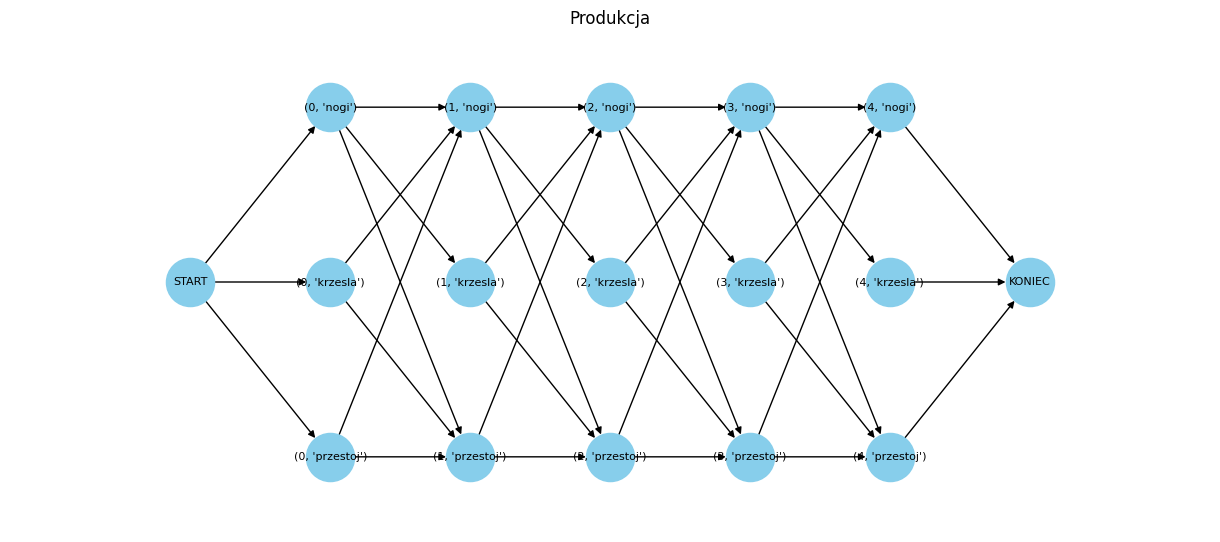

In [ ]:
n = len(CENY["drewno"])
tryb_y = {"nogi": 2, "krzesla": 1, "przestoj": 0}

pos = {}
for t in range(n):
  for tryb in TRYBY:
    pos[(t, tryb)] = (t + 1, tryb_y[tryb])

pos["START"] = (0, 1)
pos["KONIEC"] = (n+1, 1)

# wizualziacja
plt.figure(figsize=(12, 5))
nx.draw(G,
        pos,
        with_labels=True,
        node_color='skyblue',
        node_size=1200,
        font_size=8,
        arrows=True
        )
plt.title("Produkcja")
plt.margins(0.15)
plt.show()

### Etap 5 Scenariusze



**Scenariusz A (bazowy)**

>>> Scenariusz bazowy (ceny wahające się):
------Plan Produkcji------
Tydzień 1: krzesla -> 34
Tydzień 2: przestoj -> -13
Tydzień 3: przestoj -> -5
Tydzień 4: nogi -> -29
Tydzień 5: krzesla -> 20

----------------------
Maks. zysk (dist): 7
Suma cząstkowa: 7


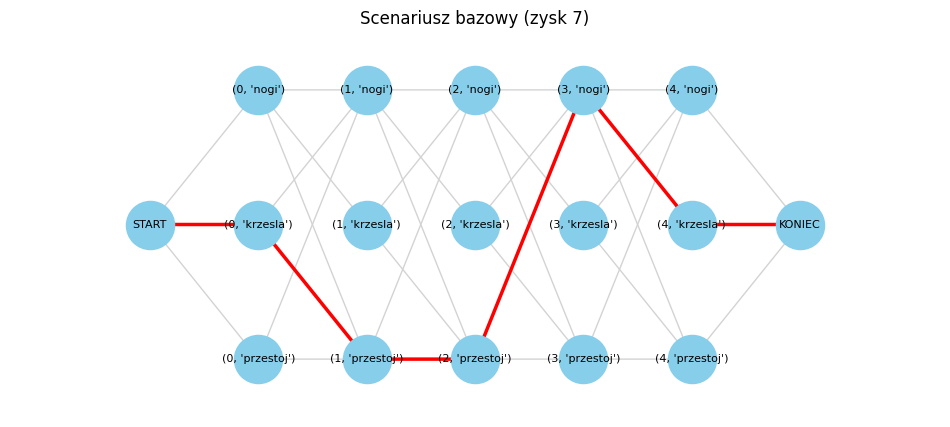

In [ ]:
print(">>> Scenariusz bazowy (ceny wahające się):")
G_bazowy = zbuduj_graf(CENY, PARAMS)
plan_bazowy, _ = pokaz_wynik(G_bazowy)
rysuj_ze_sciezka(G_bazowy, plan_bazowy, "Scenariusz bazowy (zysk 7)")

**Scenariusz B:** tani, stabilny rynek surowców



>>> Scenariusz B (tani, stabilny rynek):
------Plan Produkcji------
Tydzień 1: krzesla -> 46
Tydzień 2: nogi -> -23
Tydzień 3: krzesla -> 38
Tydzień 4: nogi -> -23
Tydzień 5: krzesla -> 38

----------------------
Maks. zysk (dist): 76
Suma cząstkowa: 76


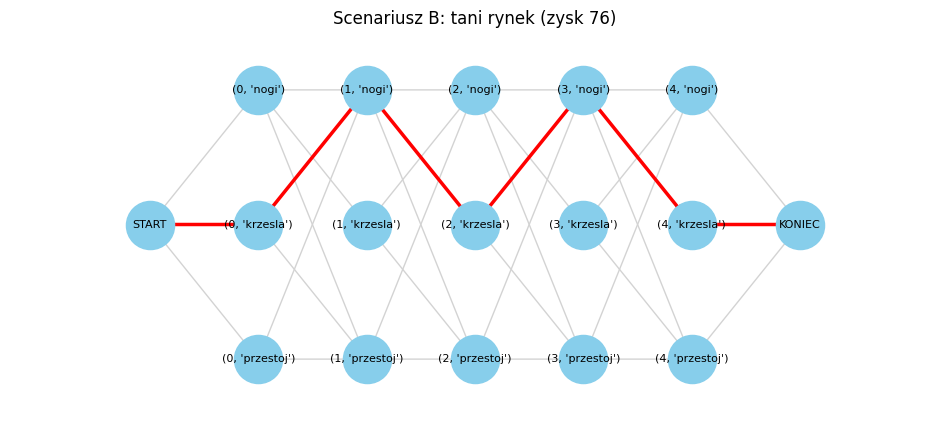

In [ ]:
# Scenariusz B: tani, stabilny rynek surowców
CENY_TANIE = {
    "drewno": [5, 5, 5, 5, 5],
    "lakier": [2, 2, 2, 2, 2],
}

print("\n>>> Scenariusz B (tani, stabilny rynek):")
G_tanie = zbuduj_graf(CENY_TANIE, PARAMS)
plan_b, _ = pokaz_wynik(G_tanie)
rysuj_ze_sciezka(G_tanie, plan_b, "Scenariusz B: tani rynek (zysk 76)")

**Scenariusz C:** z ograniczeniem budżetu drewna


>>> Z ograniczeniem budżetu drewna = 6:
------ Plan Produkcji (budżet drewna = 6) ------
Tydzień 1: krzesla -> zysk 34, drewno 2
Tydzień 2: przestoj -> zysk -13, drewno 0
Tydzień 3: przestoj -> zysk -5, drewno 0
Tydzień 4: przestoj -> zysk -5, drewno 0
Tydzień 5: przestoj -> zysk -5, drewno 0
-----------------------------------------
Maks. zysk (dist): 6
Suma cząstkowa:    6
Drewno zużyte:     2 / 6


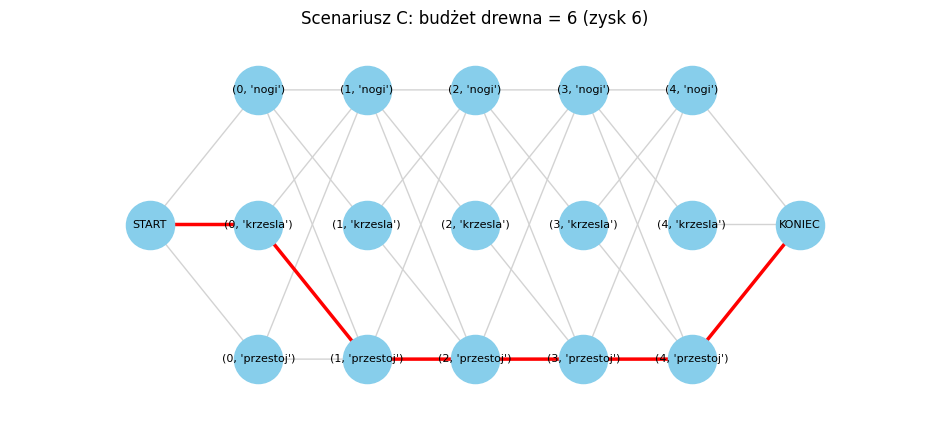

In [ ]:
G_c = zbuduj_graf(CENY, PARAMS)

print("\n>>> Z ograniczeniem budżetu drewna = 6:")
plan_c, _ = pokaz_wynik_budzet(G_c, 6)
rysuj_ze_sciezka(G_c, plan_c, "Scenariusz C: budżet drewna = 6 (zysk 6)")

**Wykres Cen**

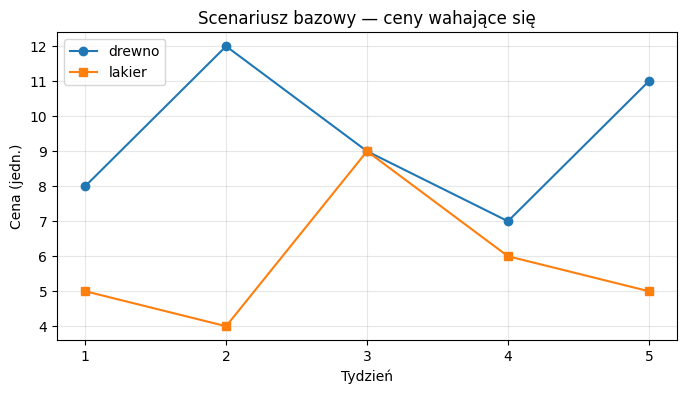

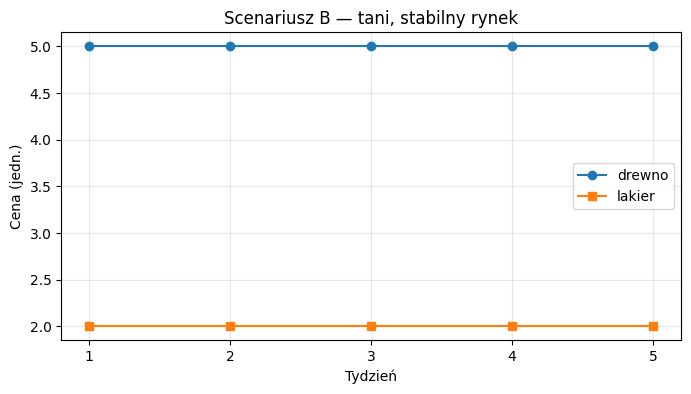

In [ ]:
rysuj_ceny(CENY, "Scenariusz bazowy — ceny wahające się")
rysuj_ceny(CENY_TANIE, "Scenariusz B — tani, stabilny rynek")

## 6. Opracowanie wyników

### 6.1 Weryfikacja poprawności
Algorytm sprawdziłem przeglądem zupełnym (brute-force) - policzyłem wszystkie legalne plany i porównałem z wynikiem BF. W każdym scenariuszu wynik się zgadza.

Dodatkowo w każdym przypadku suma zysków cząstkowych = maksymalny zysk (`dist[KONIEC]`), co potwierdza wewnętrzną spójność.

- bazowy: optimum = 7 (potwierdzone brute-force)
- budżetowy: optimum = 6 (potwierdzone brute-force)

W scenariuszu budżetowym heurystyka greedy (sposób B) trafiła w globalne optimum, mimo że w ogólności nie daje takiej gwarancji (patrz 6.4).

### 6.2 Scenariusz bazowy - ceny wahające się
Plan: krzesła, przestój, przestój, nogi, krzesła (zysk 7).

Fabryka produkuje krzesła w pierwszym tygodniu (tanie surowce), potem przeczekuje dwa drogie tygodnie w przestoju. W tygodniu 4 inwestuje w nogi (strata -29), żeby w tygodniu 5 zarobić na krzesłach (+20).

Ciekawa obserwacja: przestój bywa optymalny. Czasem taniej nic nie robić niż produkować ze stratą. Na wykresie cen widać skok lakieru w tygodniu 3 - to tłumaczy, czemu środek planu to przestoje.

### 6.3 Scenariusz B - tani, stabilny rynek
Plan: krzesła, nogi, krzesła, nogi, krzesła (zysk 76).

Gdy surowce są tanie i przewidywalne, opłaca się produkować bez przerwy. Widać pełną naprzemienność - reguła zależności wymusza nogi przed każdą turą krzeseł.

Najważniejsze: ta sama fabryka i ten sam algorytm, tylko inne ceny, a strategia zmienia się całkowicie (7 -> 76). To pokazuje wpływ dynamiki cen na plan. Na wykresie cen widać dwie płaskie linie nisko - brak ryzyka, więc produkujemy ile się da.

### 6.4 Scenariusz C - ograniczenie budżetu drewna
Plan: krzesła, przestój, przestój, przestój, przestój (zysk 6, drewno 2/6).

Przy limicie 6 jednostek drewna fabryka nie może pozwolić sobie na drugą turę nóg (potrzebne w tygodniu 4). Rezygnuje z produkcji w drugiej połowie i zysk spada z 7 na 6.

To pokazuje działanie feasibility-check w relaksacji (z 3.2) - ograniczenie realnie przycina plan, a nie jest tylko teorią. Na wykresie ścieżki widać, że czerwona trasa schodzi w dół i idzie przez same przestoje.

Uczciwa uwaga: sposób B to heurystyka. Trzyma tylko stan najlepszy pod względem zysku, więc może odrzucić ścieżkę oszczędniejszą w drewnie, która dałaby lepszy wynik w ramach budżetu. Na moich danych trafił w optimum (sprawdzone brute-force), ale pełną gwarancję dałoby rozszerzenie stanu o zużyte drewno.

### 6.5 Wnioski
- zmodyfikowany Bellman-Ford (maksimum zamiast minimum, na DAG-u) skutecznie znajduje optymalny plan produkcji
- model grafowy obejmuje wszystkie wymagane elementy: dynamiczne ceny (wagi zależne od tygodnia), zależności produktowe (filtr krawędzi), ograniczenia zasobowe (feasibility w relaksacji)
- struktura DAG gwarantuje poprawność i wielomianową złożoność
- dalszy rozwój: pełne rozszerzenie stanu (poprawność przy budżecie), magazyn kumulatywny, więcej produktów